In [3]:
import json, re
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from itertools import chain
from collections import Counter


In [4]:
raw_data = Path("games_export.csv")
out_data = Path("data/processed"); out_data.mkdir(parents=True, exist_ok=True)

chess_dataset = pd.read_csv(raw_data)

In [5]:
MIN_PLIES = 3 # smallest length that gives enough context for next-move prediction
MIN_ITEM_COUNT = 5 
VAL_FRAC = TEST_FRAC = 0.1
BAND_ORDER = ["<1200", "1200-1599", "1600-1999", "2000-2199", "2200+"]

In [6]:
#Load
df = pd.read_csv(raw_data)
df['created_at'] = pd.to_datetime(df['created_at'], unit='ms')
df['last_move_at'] = pd.to_datetime(df['last_move_at'], unit='ms')

print(df.shape, "| nulls:", df.isnull().sum())


(20058, 16) | nulls: id                0
rated             0
created_at        0
last_move_at      0
turns             0
victory_status    0
winner            0
increment_code    0
white_id          0
white_rating      0
black_id          0
black_rating      0
moves             0
opening_eco       0
opening_name      0
opening_ply       0
dtype: int64


no nulls to process

In [7]:
df.head(5)

df.describe(include='all').T

,count,unique,top,freq,mean,min,25%,50%,75%,max,std
id,20058,19113,XRuQPSzH,5,NaN,NaN,NaN,NaN,NaN,NaN,NaN
rated,20058,2,True,16155,NaN,NaN,NaN,NaN,NaN,NaN,NaN
created_at,20058,NaN,NaN,NaN,2017-01-05 11:47:32.629000,2013-08-17 20:33:53.173000,2016-10-27 05:51:40,2017-05-28 22:20:00,2017-08-19 19:13:20,2017-09-04 02:45:43.790000,NaN
last_move_at,20058,NaN,NaN,NaN,2017-01-05 12:02:02.336000,2013-08-17 20:37:43.841000,2016-10-27 05:51:40,2017-05-28 22:20:00,2017-08-19 19:13:20,2017-09-04 02:57:07.262000,NaN
turns,20058.0,NaN,NaN,NaN,60.465999,1.0,37.0,55.0,79.0,349.0,33.570585
victory_status,20058,4,resign,11147,NaN,NaN,NaN,NaN,NaN,NaN,NaN
winner,20058,3,white,10001,NaN,NaN,NaN,NaN,NaN,NaN,NaN
increment_code,20058,400,10+0,7721,NaN,NaN,NaN,NaN,NaN,NaN,NaN
white_id,20058,9438,taranga,72,NaN,NaN,NaN,NaN,NaN,NaN,NaN
white_rating,20058.0,NaN,NaN,NaN,1596.631868,784.0,1398.0,1567.0,1793.0,2700.0,291.253376


## Data Cleaning & Preprocessing


In [8]:
# deduping replicated ids with same moves, but checking for any conflicts

dup = df["id"].duplicated(keep=False)
conflicted_dup = (df[dup].groupby("id")["moves"].nunique() > 1).sum()

print(f"duplicated ids: {dup.sum()}, conflicted duplicated ids: {conflicted_dup}")

assert conflicted_dup == 0, "There are duplicated ids with different moves. Please check the data."

duplicated ids: 1758, conflicted duplicated ids: 0


In [9]:
df = df.drop_duplicates("id", keep="first")
df.shape

(19113, 16)

No. of entries removed due to re-entries with same id and moves = 20058 - 19113 = 945 entries


In [10]:
game_key = ["white_id", "black_id", "created_at", "moves"]
print(f"no. of pairs of game under different id: {df.duplicated(game_key).sum()}")
same_game = df[df.duplicated(game_key, keep=False)].sort_values(game_key + ["id"])
same_game

no. of pairs of game under different id: 2


,id,rated,created_at,last_move_at,turns,victory_status,winner,increment_code,white_id,white_rating,black_id,black_rating,moves,opening_eco,opening_name,opening_ply
864,V7a3QIoB,True,2017-07-13 01:40:00,2017-07-13 01:40:00,4,mate,black,10+0,duckduckfrog,1533,smartduckduckcow,1897,f4 e6 g4 Qh4#,A02,Bird Opening,1
867,pSa9EQDs,True,2017-07-13 01:40:00,2017-07-13 01:40:00,4,mate,black,10+0,duckduckfrog,1552,smartduckduckcow,1887,f4 e6 g4 Qh4#,A02,Bird Opening,1
5462,QjqIySkz,True,2016-06-14 13:13:20,2016-06-14 13:13:20,7,mate,white,9+0,zalgiris15,1690,qqqirmantas,1149,e4 a6 Bc4 Ra7 Qf3 Ra8 Qxf7#,B00,St. George Defense,2
5461,pFsFrttE,True,2016-06-14 13:13:20,2016-06-14 13:13:20,7,mate,white,9+0,zalgiris15,1693,qqqirmantas,1144,e4 a6 Bc4 Ra7 Qf3 Ra8 Qxf7#,B00,St. George Defense,2


In [11]:
df = df.drop_duplicates(game_key, keep="first")
df.shape

(19111, 16)

In [12]:
# tokenising "moves" column
SAN_RE = re.compile(r"^(O-O(-O)?|[KQRBN]?[a-h]?[1-8]?x?[a-h][1-8](=[QRBN])?)[+#]?$")

def tokenise(moves: str) -> list[str]:
    toks = moves.split()
    bad = [t for t in toks if not SAN_RE.match(t)]
    if bad:
        raise ValueError(f"non-SAN tokens: {bad[:5]}")
    return [f"{'w' if i % 2 == 0 else 'b'}:{t}" for i, t in enumerate(toks)]

df["tokens"] = df["moves"].map(tokenise)
df["n_plies"] = df["tokens"].str.len()

assert (df["n_plies"] == df["turns"]).all(), "turns column disagrees with move count"
assert (df["opening_ply"] <= df["n_plies"]).all()

In [13]:
# remove short session games <3 turns (not useful for next-move prediction)
before = len(df)
df = df[df["n_plies"] >= MIN_PLIES].copy()
print(f"dropped {before - len(df)} games with < {MIN_PLIES} plies")
print("games remaining:", len(df))
print(f"length percentiles: {df['n_plies'].quantile([.5, .9, .99, 1]).astype(int).to_dict()}") # used to pick GRU window size

dropped 194 games with < 3 plies
games remaining: 18917
length percentiles: {0.5: 56, 0.9: 107, 0.99: 157, 1.0: 349}


## Feature engineering

In [14]:
# Creating new features for analysis derived from existing columns

# 1. overall skill level of the game
df["rating_mean"] = (df["white_rating"] + df["black_rating"]) / 2

# 2. rating difference between the two players
df["rating_diff"] = df["white_rating"] - df["black_rating"]          # positive means white is stronger

# 3. rating band for the game based on rating_mean
df["rating_band"] = pd.cut(df["rating_mean"], [0, 1200, 1600, 2000, 2200, np.inf], labels=BAND_ORDER).astype(str)

# 4. proxy of how easy the next-move predicttion is at the start of the session
df["eco_letter"] = df["opening_eco"].str[0]

df[["rating_mean", "rating_diff", "rating_band", "eco_letter"]].describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
rating_mean,18917.0,NaN,NaN,NaN,1595.259899,261.31435,827.0,1411.5,1571.0,1773.0,2475.5
rating_diff,18917.0,NaN,NaN,NaN,7.214199,244.808523,-1605.0,-107.0,3.0,121.0,1499.0
rating_band,18917,5,1200-1599,9228,NaN,NaN,NaN,NaN,NaN,NaN,NaN
eco_letter,18917,5,C,7244,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Data Splitting


In [15]:
# temporal split of train/val/test sets, with the most recent games in the test set, and the next most recent games in the validation set. 
df = df.sort_values("created_at", kind="stable").reset_index(drop=True)

n = len(df)
n_test = int(n * TEST_FRAC)
n_val = int(n * VAL_FRAC)

split_labels = np.array(["train"] * n)

split_labels[n - n_val - n_test : n - n_test] = "val"
split_labels[n - n_test :] = "test"

df["split"] = split_labels

print(df.groupby("split")["created_at"].agg(["count", "min", "max"]))

train_tokens_series = df.loc[df["split"] == "train", "tokens"]
train_counts = Counter(chain.from_iterable(train_tokens_series)) # number of times each token appears in the training set

       count                     min                     max
split                                                       
test    1891 2017-08-30 22:46:37.861 2017-09-04 02:45:43.790
train  15135 2013-08-17 20:33:53.173 2017-08-24 21:26:40.000
val     1891 2017-08-24 21:26:40.000 2017-08-30 22:35:58.845


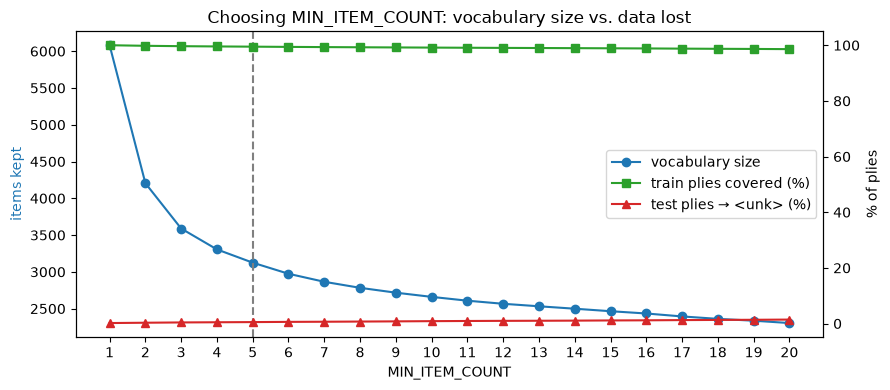

In [16]:
thresholds = np.arange(1, 21)
tot = sum(train_counts.values())
test_tokens = list(chain.from_iterable(df.loc[df["split"] == "test", "tokens"]))

vocab_size = [sum(c >= k for c in train_counts.values()) for k in thresholds]
coverage   = [sum(c for c in train_counts.values() if c >= k) / tot for k in thresholds]
test_unk   = [sum(train_counts.get(t, 0) < k for t in test_tokens) / len(test_tokens) for k in thresholds]

fig, ax1 = plt.subplots(figsize=(9, 4))
ax1.plot(thresholds, vocab_size, marker="o", color="tab:blue", label="vocabulary size")
ax1.set_xlabel("MIN_ITEM_COUNT"); ax1.set_ylabel("items kept", color="tab:blue")
ax1.set_xticks(thresholds)

ax2 = ax1.twinx()
ax2.plot(thresholds, [c * 100 for c in coverage], marker="s", color="tab:green", label="train plies covered (%)")
ax2.plot(thresholds, [u * 100 for u in test_unk], marker="^", color="tab:red", label="test plies → <unk> (%)")
ax2.set_ylabel("% of plies")

ax1.axvline(MIN_ITEM_COUNT, ls="--", color="grey")
ax1.set_title("Choosing MIN_ITEM_COUNT: vocabulary size vs. data lost")
h1, l1 = ax1.get_legend_handles_labels(); h2, l2 = ax2.get_legend_handles_labels()
ax1.legend(h1 + h2, l1 + l2, loc="center right")
plt.tight_layout()


In [ ]:
vocab = sorted(t for t, c in train_counts.items() if c >= MIN_ITEM_COUNT)
UNK = "<unk>"
item2idx = {UNK: 0, **{t: i + 1 for i, t in enumerate(vocab)}}   
coverage = sum(c for t, c in train_counts.items() if t in item2idx) / sum(train_counts.values())
print(f"train tokens: {sum(train_counts.values()):,}  unique: {len(train_counts):,}  "
      f"kept (>= {MIN_ITEM_COUNT}): {len(vocab):,}  coverage: {coverage:.4%}")

n_unk = {name: sum(t not in item2idx for toks in part["tokens"] for t in toks)
         for name, part in df.groupby("split")}
print("plies mapped to <unk>:", n_unk)
df["tokens"] = df["tokens"].map(lambda toks: [t if t in item2idx else UNK for t in toks])

train tokens: 905,713  unique: 6,081  kept (>= 5): 3,125  coverage: 99.4833%
plies mapped to <unk>: {'test': 663, 'train': 4680, 'val': 717}


### Choosing `MIN_ITEM_COUNT`

Every distinct move token (`w:e4`, `b:Nf6`, `w:Qxh7#`, …) is an *item* the model can recommend.
The training set contains **6,081** distinct tokens, but their frequencies are extremely skewed:
a few hundred common moves account for almost all plies, while roughly half of the tokens
appear fewer than 5 times in 15,000 games (rare checkmates, unusual promotions, odd captures).

A model cannot learn anything useful about a move it has seen twice — its embedding stays random —
yet every kept token adds a row to the output layer and can be wrongly recommended. So we keep only
tokens that occur at least `MIN_ITEM_COUNT` times in the **training** games and map the rest to a
single `<unk>` item (index 0), which is never used as a prediction target.

The plot shows the trade-off for thresholds 1–20:

- **Vocabulary size** (blue) falls steeply from 6,081 to ~3,100 as the threshold rises to 5, then flattens.
- **Training plies covered** (green) stays at ~99.5% throughout — the rare tokens are only 0.5% of the data.
- **Test plies mapped to `<unk>`** (red) stays around 0.5% — the number of test targets we cannot score barely changes.

`MIN_ITEM_COUNT = 5` sits just past the knee of the blue curve: it halves the output layer
(6,081 → 3,125 items) while losing only 0.5% of training plies and 0.5% of test targets.
Lower values re-add hundreds of items the model cannot learn; higher values shrink the vocabulary
further but with diminishing returns. The value 5 is also the threshold used in the original
GRU4Rec paper (Hidasi et al., 2016), which makes our results comparable to the literature.

The vocabulary is built from training games only, so the test set has no influence on which moves the model is able to recommend.


In [ ]:
feature_cols = ["id", "split", "created_at", "rated",
                "white_rating", "black_rating", "rating_mean", "rating_diff", "rating_band",
                "victory_status", "winner", "opening_eco", "eco_letter", "opening_name", "opening_ply",
                "n_plies", "tokens"]
games_clean = df[feature_cols].reset_index(drop=True)
games_clean.to_parquet(out_data / "games_clean.parquet", index=False)

long = (games_clean[["id", "split", "winner", "opening_ply", "tokens"]].explode("tokens").rename(columns={"id": "session_id", "tokens": "item"}))
long["position"] = long.groupby("session_id").cumcount().astype("int16")
long["item_idx"] = long["item"].map(item2idx).astype("int32")
long["side"] = np.where(long["position"] % 2 == 0, "w", "b")          
long["is_winner_move"] = long["side"] == long["winner"].str[0]        
long["in_book"] = long["position"] < long["opening_ply"]
long = long.reset_index(drop=True)

assert ((long["item"] == UNK) | (long["item"].str[0] == long["side"])).all(), "side/position parity broken"

cols = ["session_id", "position", "item_idx", "side", "is_winner_move", "in_book"]
for name, part in long.groupby("split"):
    part[cols].to_parquet(out_data / f"{name}.parquet", index=False)
    n_targets = (part["is_winner_move"] & (part["item_idx"] > 0)).sum()
    print(f"{name:5s} rows={len(part):>7,}  winner-move targets={n_targets:>7,}  <unk>={(part['item_idx'] == 0).sum():,}")

(out_data / "item2idx.json").write_text(json.dumps(item2idx))
long[cols].head(8)

test  rows=125,572  winner-move targets= 58,214  <unk>=663
train rows=905,713  winner-move targets=423,486  <unk>=4,680
val   rows=124,934  winner-move targets= 57,517  <unk>=717


,session_id,position,item_idx,side,is_winner_move,in_book
0,hmdl0w8w,0,3012,w,True,True
1,hmdl0w8w,1,1438,b,False,True
2,hmdl0w8w,2,2348,w,True,True
3,hmdl0w8w,3,474,b,False,True
4,hmdl0w8w,4,2434,w,True,False
5,hmdl0w8w,5,70,b,False,False
6,hmdl0w8w,6,2926,w,True,False
7,hmdl0w8w,7,1415,b,False,False
